### Download dataset and convert to Pandas dataframe

In [ ]:
# installed but not in requirements.txt, so check version
! pip show kagglehub | grep "Version" | head -n 1

In [ ]:
import kagglehub
import pandas as pd

/home/libero/nndl_final_project/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
def download_dataset(
    year_start,
    year_end_exd,
    origin_path="flnny123/mfddmulti-modal-flight-delay-dataset/versions/4",
    mode="tabular",  # or "sequential" for pre-made chains
    output_dir_seq="data/chain/",
):

    dest_paths = []
    for year in range(year_start, year_end_exd):
        print(f"Downloading year {year} data...")
        if mode == "tabular":
            origin_path_year = (
                "Aeolus/Flight_Tab/flight_with_weather_" + str(year) + ".csv"
            )
            dest_path_year = kagglehub.dataset_download(
                origin_path, path=origin_path_year
            )
            dest_paths.append(dest_path_year)

        # dest_path_year = dest_path+'flight_with_weather_'+str(year)+'.csv' # destination path
        elif mode == "sequential":
            for split in ["train", "val", "test"]:
                origin_path_year_split = f"Aeolus/Flight_chain/chain_data_{year}/{split}_flight_chain_{year}.pt"
                final_path = os.path.join(
                    output_dir_seq + str(year), f"{split}_flight_chain_{year}.pt"
                )
                if os.path.exists(final_path):
                    print(f"Path {final_path} already exists! Skipping it")
                    continue
                dest_path_year = kagglehub.dataset_download(
                    origin_path, path=origin_path_year_split
                )
                os.makedirs(output_dir_seq + str(year), exist_ok=True)
                shutil.move(dest_path_year, final_path)
                dest_path_year = final_path
                dest_paths.append(final_path)

                print(f"(File(s) available at {dest_path_year}).")

    return dest_paths


def read_dataset_pandas(  # for tabular
    file_path_year, exploring=True
):  # if True, get limited number of rows to avoid memory issues):
    print("Converting to Pandas dataframe...")
    if exploring:
        df = pd.read_csv(file_path_year, nrows=10000)
    else:
        df = pd.read_csv(file_path_year)
    print("All done.")
    return df


def load_dataset_pytorch(
    year, file_path="data/chain/"
):  # for sequential when directly available
    split_types = ["train", "val", "test"]

    loaded_data = {}

    for split in split_types:
        full_file_path = file_path + f"{year}/{split}_flight_chain_{year}.pt"
        loaded_data[split] = torch.load(full_file_path, weights_only=False)

        print(f"--- Read file: (split: {split}, year: {year}) ---")

    return loaded_data


In [ ]:
dfs_paths= download_dataset(year_start=2022, year_end_exd=2023)


(CSV file available at /home/libero/.cache/kagglehub/datasets/flnny123/mfddmulti-modal-flight-delay-dataset/versions/4/Aeolus/Flight_Tab/flight_with_weather_2022.csv).


In [ ]:
df_2022_path=dfs_paths[0]
df_2022= read_dataset_pandas(file_path_year=df_2022_path,
                             exploring=True) # if True, get limited number of rows to avoid memory issues):


Converting to Pandas dataframe...


All done.


### Explore

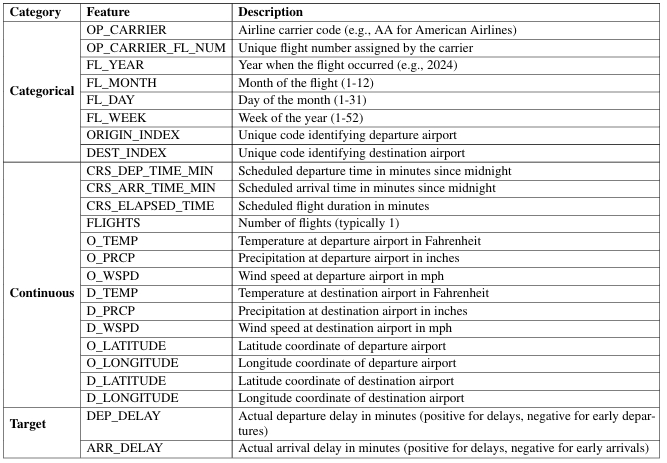

In [ ]:
from IPython import display
display.Image("/mnt/c/Users/Libero/uni/1B/nndl_final_project_theory/features_explained.jpeg")

In [ ]:
# WHEELS_ON and WHEELS_OFF likely represent actual landing and takeoff times respectively??
# (so they should be considered targets);
# also assuming all times are in the same timezone??

In [ ]:
#type(df_2022)

In [ ]:
#type(df_2022_path)

In [ ]:
#df_2022.iloc[:,:15].tail()

In [ ]:
#df_2022.iloc[:,15:].head()

In [ ]:
#df_2022.sort_values(by="AIR_TIME").tail(1)["AIR_TIME"] # longest airtime

In [ ]:
#df_2022.dtypes

### Clean up

In [ ]:
# define column names as global variables
DATE_COLS=["FL_DATE"]
DATETIME_COLS=["CRS_DEP_TIME", "CRS_ARR_TIME", "DEP_TIME",
               "ARR_TIME", "WHEELS_OFF", "WHEELS_ON", ]
TIMEDELTA_MINS_COLS=["DEP_DELAY", "ARR_DELAY", "TAXI_OUT", "TAXI_IN", "CRS_ELAPSED_TIME",
                     "ACTUAL_ELAPSED_TIME", "AIR_TIME",	]
INT_COLS=["OP_CARRIER_FL_NUM", "FLIGHTS", "MONTH", "DAY_OF_MONTH",
          "DAY_OF_WEEK", "ORIGIN_INDEX", "DEST_INDEX"]
STR_COLS=["OP_CARRIER", "ORIGIN", "DEST"]
FLOAT_COLS=["O_TEMP", "O_PRCP", "O_WSPD", "D_TEMP", "D_PRCP", "D_WSPD", "O_LATITUDE",
             "O_LONGITUDE", "D_LATITUDE", "D_LONGITUDE"]
size_set_check=set(DATE_COLS+DATETIME_COLS+TIMEDELTA_MINS_COLS+INT_COLS+STR_COLS+FLOAT_COLS)
print(f"Total individual features (should be 34): {len(size_set_check)}")

Total individual features (should be 34): 34


In [ ]:
def remove_outliers_percentile(df, columns, lower=0.01, upper=0.99): # good practice 
    n_rows_before=len(df)
    for col in columns:
        lower_bound = df[col].quantile(lower)
        upper_bound = df[col].quantile(upper)
        df= df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    n_rows_after=len(df)
    percentage_dropped=100 *(n_rows_before-n_rows_after)/n_rows_before 
    print(f"Dropped {percentage_dropped:.2f} % of rows because outliers.")
        
    return df

In [ ]:
import numpy as np

In [ ]:
def clean_dataframe(
    df,
    int_type="int32",
    float_type="float32",
    cache_bool=False,
):  # cache=False to save memory at the cost of speed
    # type conversions
    for col in DATE_COLS + DATETIME_COLS:
        df[col] = pd.to_datetime(df[col], format="%Y-%m-%d %H:%M:%S", cache=cache_bool)
    for col in DATE_COLS:
        df[col] = df[col].dt.normalize()  # keep date only, no time (cleaner)
    for col in TIMEDELTA_MINS_COLS:
        df[col] = pd.to_timedelta(df[col], unit="m")
    df[INT_COLS] = df[INT_COLS].astype(int_type)
    df[STR_COLS] = df[STR_COLS].astype("str")
    df[FLOAT_COLS] = df[FLOAT_COLS].astype(float_type) # limit precision??

    # drop all rows containing NaNs and keep track of them
    n_rows_before = len(df)
    df.dropna(subset=["D_TEMP", "D_PRCP", "D_WSPD"], inplace=True)
    n_rows_after = len(df)
    n_rows_dropped = n_rows_before - n_rows_after
    print(f"Dropped {n_rows_dropped} rows because of NaNs.")
    nan_bool = bool(np.any(df_2022.isna().sum() > 0))
    print(f"Any NaNs remaining in numerical data: {nan_bool}.")

    return df

In [ ]:
df_2022=clean_dataframe(df_2022)

Dropped 0 rows because of NaNs.
Any NaNs remaining in numerical data: False.


In [ ]:
#df_2022.dtypes

In [ ]:
df_2022.head()

,FL_DATE,OP_CARRIER,OP_CARRIER_FL_NUM,ORIGIN,DEST,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,TAXI_OUT,WHEELS_OFF,...,O_TEMP,O_PRCP,O_WSPD,D_TEMP,D_PRCP,D_WSPD,O_LATITUDE,O_LONGITUDE,D_LATITUDE,D_LONGITUDE
0,2022-01-01,9E,4628,DTW,RDU,2022-01-01 09:30:00,2022-01-01 09:25:00,-1 days +23:55:00,0 days 00:10:00,2022-01-01 09:35:00,...,6.7,0.0,9.400000,19.4,0.0,14.800000,42.212059,-83.348839,35.87764,-78.787468
1,2022-01-01,DL,2812,DTW,RDU,2022-01-01 15:50:00,2022-01-01 15:49:00,-1 days +23:59:00,0 days 00:10:00,2022-01-01 15:59:00,...,3.9,0.0,22.299999,24.4,0.0,31.700001,42.212059,-83.348839,35.87764,-78.787468
2,2022-01-02,9E,4647,DTW,RDU,2022-01-02 10:31:00,2022-01-02 10:57:00,0 days 00:26:00,0 days 01:03:00,2022-01-02 12:00:00,...,-3.3,0.0,24.100000,20.0,3.3,16.600000,42.212059,-83.348839,35.87764,-78.787468
3,2022-01-02,9E,4896,DTW,RDU,2022-01-02 07:00:00,2022-01-02 07:24:00,0 days 00:24:00,0 days 00:44:00,2022-01-02 08:08:00,...,-2.2,0.3,20.500000,21.1,0.0,35.299999,42.212059,-83.348839,35.87764,-78.787468
4,2022-01-02,9E,5017,DTW,RDU,2022-01-02 15:50:00,2022-01-02 16:39:00,0 days 00:49:00,0 days 00:26:00,2022-01-02 17:05:00,...,-3.9,0.0,24.100000,19.4,0.0,13.000000,42.212059,-83.348839,35.87764,-78.787468


In [ ]:
#df_2022.columns[np.where(df_2022.isna().sum()>0)]

In [ ]:
#df_2022[pd.isna(df_2022['D_TEMP'])]

In [ ]:
#df_2022[pd.isna(df_2022['D_PRCP'])]

In [ ]:
#df_2022[pd.isna(df_2022['D_WSPD'])]

In [ ]:
#df_2022.iloc[:,:15].head()

In [ ]:
#df_2022.iloc[:,15:].head()

### Prepare dataset for tabular / sequential experiments

In [ ]:
from sklearn.preprocessing import (
    LabelEncoder,
)  # to encode categorical features as integers
import torch
from torch.utils.data import TensorDataset
import os # to save later
import time

In [ ]:
def create_flight_chains(df):
    df_sorted = df.sort_values(
        by=["OP_CARRIER", "OP_CARRIER_FL_NUM", "FL_DATE", "CRS_DEP_TIME"]
    )
    grouped = df_sorted.groupby(
        ["OP_CARRIER", "OP_CARRIER_FL_NUM", "FL_DATE"]
    )  # unique aircraft identifiers
    res = {name: group for name, group in grouped}  # dict
    return res

In [ ]:
# Truncation/padding for single chain
def adjust_sequence(data, max_len):
    if len(data) < max_len:
        pad_shape = (max_len - len(data), data.shape[1])
        return torch.cat([data, torch.zeros(pad_shape, dtype=data.dtype)], dim=0)
    return data[:max_len]

In [ ]:
def process_all_chains(
    flight_chains,
    target_columns,
    dense_feat_cols,
    sparse_feat_cols,
    max_sequence_length,
    year,  # for saving to torch dataset with proper name
):
    processed = []
    for name, chain in flight_chains.items():
        dense_tensors = [
            torch.tensor(
                chain[name].fillna(0).values, dtype=torch.float32
            )  # handle NaNs; NNs expect float
            for name in dense_feat_cols
        ]
        dense_feat = torch.stack(
            dense_tensors, dim=1
        )  # stacks columns horizontally, resulting shape (seq_len, num_dense_features)

        # feature engineering
        chain["MONTH"] = (chain["MONTH"] - 1).astype(
            np.int16
        )  # standard 0-based embedding + store as int16 to save memory
        chain["DAY_OF_WEEK"] = (chain["DAY_OF_WEEK"] - 1).astype(np.int16)

        sparse_tensors = [
            torch.tensor(
                chain[name].values.astype(np.int16), dtype=torch.int16
            )  # categorical columns should not have NAs
            for name in sparse_feat_cols
        ]
        sparse_feat = torch.stack(sparse_tensors, dim=1)

        # labels for binary classification + full delays
        # have to convert to minutes since it's a timedelta object
        delays = torch.tensor(
            (
                chain[target_columns].apply(lambda s: s.dt.total_seconds() / 60)
            ).values.astype(np.int16),
            dtype=torch.int16,
        )

        labels = torch.tensor(
            np.column_stack(
                (
                    (chain["ARR_DELAY"].dt.total_seconds() / 60 > 15).astype(
                        np.int8
                    ),  # definition of delay if more than 15 min (for binary classification)
                    (chain["ARR_DELAY"].dt.total_seconds() / 60 > 15).astype(np.int8),
                )
            ),
            dtype=torch.int8,
        )

        # Sequence length processing
        valid_len = min(
            len(dense_feat), max_sequence_length
        )  # stores the actual length before padding (but after truncation). Useful later eg in loss calculation
        dense_feat = adjust_sequence(dense_feat, max_sequence_length)
        sparse_feat = adjust_sequence(sparse_feat, max_sequence_length)
        labels = adjust_sequence(labels, max_sequence_length)
        delays = adjust_sequence(delays, max_sequence_length)

        processed.append((dense_feat, sparse_feat, labels, valid_len, delays))
    return processed

In [ ]:
def create_dataset(processed_data):
    dense = torch.stack([item[0] for item in processed_data])
    sparse = torch.stack([item[1] for item in processed_data])
    labels = torch.stack([item[2] for item in processed_data])
    valid_lens = torch.tensor([item[3] for item in processed_data], dtype=torch.long)
    delays = torch.stack([item[4] for item in processed_data])
    return TensorDataset(dense, sparse, labels, valid_lens, delays)

In [ ]:
# IMPORTANT NOTE: this modifies dataframe in-place;
# if mistaken, go back to read_dataset_pandas(...)
def prepare_data(
    df,
    year,
    mode="tabular",  # tabular or sequential
    target_columns=["DEP_DELAY", "ARR_DELAY"],  # in minutes
    time_of_prediction="departure",
    seed=42,
    max_sequence_length=6,
    train_frac=0.6,
    valid_frac=0.2
):  # departure or arrival (for tabular mode)

    print(f"Start processing data for {year}...")
    start_time = time.time()
    if mode == "tabular":
        df = remove_outliers_percentile(df, target_columns)
        df = df.dropna(subset=["FL_DATE"])
        df["FL_YEAR"] = df["FL_DATE"].dt.year  # flight year...
        df.drop(columns=["FL_DATE"], inplace=True)  # ... instead of full date

        time_columns = [
            "CRS_DEP_TIME",
            "DEP_TIME",
            "WHEELS_OFF",
            "WHEELS_ON",
            "CRS_ARR_TIME",
            "ARR_TIME",
        ]
        for col in time_columns:
            df[col + "_MIN"] = df[col].dt.hour * 60 + df[col].dt.minute
            # convert time columns in minutes since midnight...
        df.drop(columns=time_columns, inplace=True)  # ... and drop the originals

        categorical_columns = [
            "OP_CARRIER",
            "OP_CARRIER_FL_NUM",
            "FL_YEAR",
            "MONTH",
            "DAY_OF_MONTH",  # unique identifier for any day;
            # scheduled?? if not, minor leak
            "ORIGIN",
            "DEST",
        ]

        # info available before actual departure time
        continuous_columns = [
            "CRS_DEP_TIME_MIN",
            "CRS_ARR_TIME_MIN",
            "FLIGHTS",
            "O_TEMP",
            "O_PRCP",
            "O_WSPD",
            "D_TEMP",
            "D_PRCP",
            "D_WSPD",
            "O_LATITUDE",
            "O_LONGITUDE",
            "D_LATITUDE",
            "D_LONGITUDE",
        ]
        if time_of_prediction == "arrival":
            # additional info available before actual arrival time (but after actual departure)
            continuous_columns = continuous_columns + [
                "DEP_TIME_MIN",
                "WHEELS_OFF_MIN", # could also try adding "TAXI_IN"?
            ]
            target_cols = ["ARR_DELAY"]
        else:
            target_cols = target_columns
        df = df[target_cols + categorical_columns + continuous_columns]
        return df

    elif mode == "sequential":
        # feature engineering
        df["CRS_DEP_TIME_HOUR"] = df["CRS_DEP_TIME"].dt.hour.astype("int8")
        df["CRS_ARR_TIME_HOUR"] = df["CRS_ARR_TIME"].dt.hour.astype("int8")

        # encode categorical features
        encoder = LabelEncoder()
        df["OP_CARRIER"] = encoder.fit_transform(df["OP_CARRIER"])
        df["OP_CARRIER_FL_NUM"] = encoder.fit_transform(df["OP_CARRIER_FL_NUM"])

        # more feature engineering
        df["MONTH"] = df["FL_DATE"].dt.month
        df["DAY_OF_YEAR"] = df["FL_DATE"].dt.dayofyear

        dense_feat_cols = [  # numeric, all stored as floats;
            # relationship between them is quantitative (eg it makes sense to think that twice the flights will somehow have twice the impact on delay)
            "O_TEMP",
            "D_TEMP",  # assuming measured at departure??
            "O_PRCP",
            "D_PRCP",
            "O_WSPD",
            "D_WSPD",
            "FLIGHTS",
        ]

        sparse_feat_cols = [  # categorical, stored as ints
            "MONTH",
            "DAY_OF_WEEK",
            "CRS_ARR_TIME_HOUR",
            "CRS_DEP_TIME_HOUR",
            "ORIGIN_INDEX",
            "DEST_INDEX",
            "OP_CARRIER",
            "OP_CARRIER_FL_NUM",
        ]

        target_cols=target_columns

        #df = df[target_cols + ["DAY_OF_YEAR"] + ["FL_DATE"] + dense_feat_cols + sparse_feat_cols]
        # from here on we include train/test split (without leaking), torch implementation, etc.
        # (group by to create multiple chains each identified by starting day of year, etc)
        # and also time of prediction

        df = df.sort_values(by="FL_DATE").reset_index(drop=True)
        date_dim = (
            df[["FL_DATE"]].drop_duplicates()
        )  # selects FL_DATE column as a dataframe to get only unique dates
        # new columsna for unique identifier
        date_dim["DAY_OF_YEAR"] = date_dim["FL_DATE"].dt.dayofyear
        date_dim["MONTH"] = date_dim["FL_DATE"].dt.month

        rng = np.random.RandomState(seed=seed)

        train_days, valid_days, test_days = [], [], []
        for month in sorted(date_dim["MONTH"].unique()):  # 1, 2, 3, ...
            month_dates = date_dim[date_dim["MONTH"] == month]["DAY_OF_YEAR"]
            n_days = len(month_dates)
            if n_days < 3:
                raise Exception(
                    f"Allocated days less than three for {month} with this seed."
                )
            #    alloc_days = list(month_dates) * 3
            #    mandatory_days = alloc_days[:3]
            # else:
            #
            mandatory_days = rng.choice(month_dates, 3, replace=False)

            train_days.append(mandatory_days[0])
            valid_days.append(mandatory_days[1])
            test_days.append(mandatory_days[2])

            remaining_days = [d for d in month_dates if d not in mandatory_days]
            n_remaining = len(remaining_days)

            if n_remaining > 0:
                permuted = rng.permutation(remaining_days)
                split1 = int(round(n_remaining * train_frac))
                split2 = split1 + int(round(n_remaining * valid_frac))

                train_days.extend(permuted[:split1])
                valid_days.extend(permuted[split1:split2])
                test_days.extend(permuted[split2:])

        date_dim["SPLIT_TYPE"] = np.select(
            [
                date_dim["DAY_OF_YEAR"].isin(train_days),
                date_dim["DAY_OF_YEAR"].isin(valid_days),
                date_dim["DAY_OF_YEAR"].isin(test_days),
            ],
            ["train", "valid", "test"],
            default="undefined",  # in case something goes wrong, split type will not be automatically deduced
        )

        df = pd.merge(df, date_dim[["FL_DATE", "SPLIT_TYPE"]], on="FL_DATE", how="left")

        train_chains = create_flight_chains(df[df["SPLIT_TYPE"] == "train"])
        valid_chains = create_flight_chains(df[df["SPLIT_TYPE"] == "valid"])
        test_chains = create_flight_chains(df[df["SPLIT_TYPE"] == "test"])

        train_processed = process_all_chains(
            train_chains,
            target_columns=target_columns,
            dense_feat_cols=dense_feat_cols,
            sparse_feat_cols=sparse_feat_cols,
            max_sequence_length=max_sequence_length,
            year=year,
        )
        valid_processed = process_all_chains(
            valid_chains,
            target_columns=target_columns,
            dense_feat_cols=dense_feat_cols,
            sparse_feat_cols=sparse_feat_cols,
            max_sequence_length=max_sequence_length,
            year=year,
        )
        test_processed = process_all_chains(
            test_chains,
            target_columns=target_columns,
            dense_feat_cols=dense_feat_cols,
            sparse_feat_cols=sparse_feat_cols,
            max_sequence_length=max_sequence_length,
            year=year,
        )

        train_dataset = create_dataset(train_processed)
        valid_dataset = create_dataset(valid_processed)
        test_dataset = create_dataset(test_processed)

        # 5. Save results
        output_dir = f"processed_data_{year}"
        os.makedirs(output_dir, exist_ok=True)

        torch.save(
            train_dataset, os.path.join(output_dir, f"train_flight_chain_{year}.pt")
        )
        torch.save(
            valid_dataset, os.path.join(output_dir, f"val_flight_chain_{year}.pt")
        )
        torch.save(
            test_dataset, os.path.join(output_dir, f"test_flight_chain_{year}.pt")
        )

        elapsed = time.time() - start_time
        print(
            f"Finished processing data for {year}, time elapsed: {elapsed:.2f} seconds"
        )
        return f"Torch dataset available at relative path: {output_dir}"


In [ ]:
df_2022 = prepare_data(df_2022, mode="tabular", time_of_prediction="arrival", year=2022)

Start processing data for 2022...
Dropped 3.59 % of rows because outliers.


In [ ]:
df_2022.iloc[:,:15].head()

,ARR_DELAY,OP_CARRIER,OP_CARRIER_FL_NUM,FL_YEAR,MONTH,DAY_OF_MONTH,ORIGIN,DEST,CRS_DEP_TIME_MIN,CRS_ARR_TIME_MIN,FLIGHTS,O_TEMP,O_PRCP,O_WSPD,D_TEMP
0,-1 days +23:31:00,9E,4628,2022,1,1,DTW,RDU,570,683,1,6.7,0.0,9.400000,19.4
1,-1 days +23:49:00,DL,2812,2022,1,1,DTW,RDU,950,1053,1,3.9,0.0,22.299999,24.4
2,0 days 01:15:00,9E,4647,2022,1,2,DTW,RDU,631,734,1,-3.3,0.0,24.100000,20.0
3,0 days 00:31:00,9E,4896,2022,1,2,DTW,RDU,420,537,1,-2.2,0.3,20.500000,21.1
4,0 days 01:17:00,9E,5017,2022,1,2,DTW,RDU,950,1058,1,-3.9,0.0,24.100000,19.4


In [ ]:
df_2022.iloc[:,15:].head()

,D_PRCP,D_WSPD,O_LATITUDE,O_LONGITUDE,D_LATITUDE,D_LONGITUDE,DEP_TIME_MIN,WHEELS_OFF_MIN
0,0.0,14.800000,42.212059,-83.348839,35.87764,-78.787468,565,575
1,0.0,31.700001,42.212059,-83.348839,35.87764,-78.787468,949,959
2,3.3,16.600000,42.212059,-83.348839,35.87764,-78.787468,657,720
3,0.0,35.299999,42.212059,-83.348839,35.87764,-78.787468,444,488
4,0.0,13.000000,42.212059,-83.348839,35.87764,-78.787468,999,1025


In [ ]:
#df_2022.dtypes

In [ ]:
prepare_data(df_2022, year= 2022, mode="sequential")

Start processing data for 2022...
Finished processing data for 2022, time elapsed: 154.99 seconds


'Torch dataset avialble at relative path: processed_data_2022'

In [ ]:
!ls -lh processed_data_2022/

total 3.0M
-rw-r--r-- 1 libero libero 625K Jul 24 19:17 test_flight_chain_2022.pt
-rw-r--r-- 1 libero libero 1.7M Jul 24 19:17 train_flight_chain_2022.pt
-rw-r--r-- 1 libero libero 658K Jul 24 19:17 val_flight_chain_2022.pt


In [ ]:
data_2022_test = torch.load("processed_data_2022/test_flight_chain_2022.pt", weights_only=False)

In [ ]:
# inspection
# Basic info
print(type(data_2022_test))
print(f"Number of chains: {len(data_2022_test)}")

# Shapes of the 5 stacked tensors (dense, sparse, labels, valid_len, delays)
print("Shapes of internal tensors:")
for i, tensor in enumerate(data_2022_test.tensors):
    print(f"  tensor {i}: {tensor.shape}, dtype: {tensor.dtype}")

# Inspect a single sample (first chain)
sample = data_2022_test[0]                 # tuple: (dense, sparse, labels, valid_len, delays)
print("\nFirst sample:")
print(f"  dense: {sample[0].shape}, dtype: {sample[0].dtype}")
print(f"  sparse: {sample[1].shape}, dtype: {sample[1].dtype}")
print(f"  labels: {sample[2].shape}, dtype: {sample[2].dtype}")
print(f"  valid_len: {sample[3]}, dtype: {sample[3].dtype}")
print(f"  delays: {sample[4].shape}, dtype: {sample[4].dtype}")

<class 'torch.utils.data.dataset.TensorDataset'>
Number of chains: 2068
Shapes of internal tensors:
  tensor 0: torch.Size([2068, 6, 7]), dtype: torch.float32
  tensor 1: torch.Size([2068, 6, 8]), dtype: torch.int16
  tensor 2: torch.Size([2068, 6, 2]), dtype: torch.int8
  tensor 3: torch.Size([2068]), dtype: torch.int64
  tensor 4: torch.Size([2068, 6, 2]), dtype: torch.int16

First sample:
  dense: torch.Size([6, 7]), dtype: torch.float32
  sparse: torch.Size([6, 8]), dtype: torch.int16
  labels: torch.Size([6, 2]), dtype: torch.int8
  valid_len: 1, dtype: torch.int64
  delays: torch.Size([6, 2]), dtype: torch.int16


In [ ]:
for i in range(0,5):
    print(sample[i])

tensor([[ 7.8000, 16.7000,  0.0000,  0.0000, 27.7000,  9.4000,  1.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000]])
tensor([[  2,   1,  21,  19, 166, 257,   0, 135],
        [  0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0]], dtype=torch.int16)
tensor([[0, 0],
        [0, 0],
        [0, 0],
        [0, 0],
        [0, 0],
        [0, 0]], dtype=torch.int8)
tensor(1)
tensor([[-1,  2],
        [ 0,  0],
        [ 0,  0],
        [ 0,  0],
        [ 0,  0],
        [ 0,  0]], dtype=t

In [ ]:
# compare with original (downloaded) Kaggle dataset:
data_2022_test_original= torch.load("/mnt/c/Users/Libero/Downloads/test_flight_chain_2022.pt", weights_only=False)


In [ ]:
print(type(data_2022_test_original))                
print(f"Number of chains: {len(data_2022_test_original)}")

# Shapes of the 5 stacked tensors 
print("Shapes of internal tensors:")
for i, tensor in enumerate(data_2022_test_original.tensors):
    print(f"  tensor {i}: {tensor.shape}, dtype: {tensor.dtype}")

# Inspect a single sample (first chain)
sample_original = data_2022_test_original[0]
print("\nFirst sample:")
print(f"  dense: {sample_original[0].shape}, dtype: {sample_original[0].dtype}")
print(f"  sparse: {sample_original[1].shape}, dtype: {sample_original[1].dtype}")
print(f"  labels: {sample_original[2].shape}, dtype: {sample_original[2].dtype}")
print(f"  valid_len: {sample_original[3]}, dtype: {sample_original[3].dtype}")
print(f"  delays: {sample_original[4].shape}, dtype: {sample_original[4].dtype}")

<class 'torch.utils.data.dataset.TensorDataset'>
Number of chains: 1081022
Shapes of internal tensors:
  tensor 0: torch.Size([1081022, 6, 7]), dtype: torch.float32
  tensor 1: torch.Size([1081022, 6, 8]), dtype: torch.int16
  tensor 2: torch.Size([1081022, 6, 2]), dtype: torch.int8
  tensor 3: torch.Size([1081022]), dtype: torch.int64
  tensor 4: torch.Size([1081022, 6, 2]), dtype: torch.int16

First sample:
  dense: torch.Size([6, 7]), dtype: torch.float32
  sparse: torch.Size([6, 8]), dtype: torch.int16
  labels: torch.Size([6, 2]), dtype: torch.int8
  valid_len: 2, dtype: torch.int64
  delays: torch.Size([6, 2]), dtype: torch.int16


In [ ]:
for i in range(0,5):
    print(sample_original[i])

tensor([[-2.0000, -1.7000,  0.0000,  0.0000, 13.0000, 13.0000,  1.0000],
        [ 0.6000, -3.0000,  0.0000,  0.0000, 20.5000, 17.0000,  1.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000]])
tensor([[   0,    0,   15,   13,  182,  319,    0, 4623],
        [   0,    0,   21,   17,  319,  182,    0, 4623],
        [   0,    0,    0,    0,    0,    0,    0,    0],
        [   0,    0,    0,    0,    0,    0,    0,    0],
        [   0,    0,    0,    0,    0,    0,    0,    0],
        [   0,    0,    0,    0,    0,    0,    0,    0]], dtype=torch.int16)
tensor([[0, 0],
        [0, 0],
        [0, 0],
        [0, 0],
        [0, 0],
        [0, 0]], dtype=torch.int8)
tensor(2)
tensor([[-16,  -9],
        [-21, -10],
        [  0,   0],
        